# MDN Data Exploration - Throw Data Query

Query database for all throw events (throws, goals, throwaways, drops) to prepare data for the Mixture Density Network model.

In [1]:
import psycopg2
from psycopg2.extras import RealDictCursor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Database Connection and Query

In [2]:
# Database connection
DB_CONFIG = {
    'dbname': 'ufa_analytics',
    'user': 'joemolder',
    'password': '',
    'host': 'localhost',
    'port': 5432
}

def get_db_connection():
    return psycopg2.connect(**DB_CONFIG, cursor_factory=RealDictCursor)

In [3]:
# Query all throw events
conn = get_db_connection()
cur = conn.cursor()

query = """
SELECT
    thrower as player_id,
    thrower_x,
    thrower_y,
    event_type,
    CASE
        WHEN event_type IN (18, 19, 20) THEN receiver_x
        WHEN event_type = 22 THEN turnover_x
    END as dest_x,
    CASE
        WHEN event_type IN (18, 19, 20) THEN receiver_y
        WHEN event_type = 22 THEN turnover_y
    END as dest_y
FROM events
WHERE thrower IS NOT NULL
    AND event_type IN (18, 19, 20, 22)
    AND thrower_x IS NOT NULL
    AND (
        (event_type IN (18, 19, 20) AND receiver_x IS NOT NULL)
        OR (event_type = 22 AND turnover_x IS NOT NULL)
    )
ORDER BY event_id;
"""

cur.execute(query)
rows = cur.fetchall()
cur.close()
conn.close()

# Convert to DataFrame
df = pd.DataFrame(rows)

print(f"Total throw events: {len(df):,}")
print(f"\nEvent type breakdown:")
print(df['event_type'].value_counts().sort_index())
print(f"\nUnique players: {df['player_id'].nunique()}")

Total throw events: 28,734

Event type breakdown:
event_type
18    24916
19     1909
20      264
22     1645
Name: count, dtype: int64

Unique players: 636


In [4]:
# Map event types to names
event_names = {
    18: 'Throw (completion)',
    19: 'Goal',
    20: 'Drop',
    22: 'Throwaway'
}
df['event_name'] = df['event_type'].map(event_names)

# Display first few rows
df.head(10)

,player_id,thrower_x,thrower_y,event_type,dest_x,dest_y,event_name
0,jbrissett,21.20,17.33,18,2.84,23.00,Throw (completion)
1,arousseau,2.84,23.00,18,17.34,18.93,Throw (completion)
2,jbrissett,17.34,18.93,22,17.34,18.93,Throwaway
3,lcomire,26.46,72.90,18,18.49,65.49,Throw (completion)
4,amuraoka,18.49,65.49,18,4.08,65.69,Throw (completion)
5,kjay,4.08,65.69,18,-14.04,70.98,Throw (completion)
6,dmiller2,-14.04,70.98,18,1.33,69.95,Throw (completion)
7,amuraoka,1.33,69.95,18,-12.94,77.84,Throw (completion)
8,bklar,-12.94,77.84,18,-3.81,83.54,Throw (completion)
9,dmiller2,-3.81,83.54,20,21.01,96.88,Drop


## 2. Data Summary Statistics

In [5]:
# Summary statistics
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)

print(f"\nTotal Events: {len(df):,}")
print(f"\nBreakdown by Event Type:")
for event_type, count in df['event_name'].value_counts().items():
    pct = (count / len(df)) * 100
    print(f"  {event_type:25s}: {count:6,} ({pct:5.2f}%)")

print(f"\nField Coordinate Ranges:")
print(f"  Thrower X: [{df['thrower_x'].min():.1f}, {df['thrower_x'].max():.1f}]")
print(f"  Thrower Y: [{df['thrower_y'].min():.1f}, {df['thrower_y'].max():.1f}]")
print(f"  Dest X:    [{df['dest_x'].min():.1f}, {df['dest_x'].max():.1f}]")
print(f"  Dest Y:    [{df['dest_y'].min():.1f}, {df['dest_y'].max():.1f}]")

DATA SUMMARY

Total Events: 28,734

Breakdown by Event Type:
  Throw (completion)       : 24,916 (86.71%)
  Goal                     :  1,909 ( 6.64%)
  Throwaway                :  1,645 ( 5.72%)
  Drop                     :    264 ( 0.92%)

Field Coordinate Ranges:
  Thrower X: [-26.7, 26.7]
  Thrower Y: [0.0, 100.0]
  Dest X:    [-26.7, 26.7]
  Dest Y:    [0.0, 120.0]


## 3. Player-Level Statistics

In [6]:
# Player-level statistics
player_stats = df.groupby('player_id').agg({
    'event_type': 'count',
    'event_name': lambda x: (x.isin(['Throw (completion)', 'Goal'])).sum()
}).rename(columns={'event_type': 'total_throws', 'event_name': 'completions'})

player_stats['turnovers'] = player_stats['total_throws'] - player_stats['completions']
player_stats['completion_rate'] = player_stats['completions'] / player_stats['total_throws']
player_stats = player_stats.sort_values('total_throws', ascending=False)

print("Top 20 players by throw volume:")
print(player_stats.head(20))

Top 20 players by throw volume:
           total_throws  completions  turnovers  completion_rate
player_id                                                       
lyorgason           325          312         13         0.960000
srueschem           291          284          7         0.975945
ndick               282          274          8         0.971631
emagsig             265          248         17         0.935849
bsadok              260          247         13         0.950000
jmiller             256          253          3         0.988281
dbarram             237          220         17         0.928270
skaminsky           228          218         10         0.956140
jmast               223          213         10         0.955157
aroy                219          213          6         0.972603
mmiller1            219          202         17         0.922374
ctrisolin           211          204          7         0.966825
ddremann            204          191         13         0.

In [7]:
# Filter players with at least 50 throws for MDN training
min_throws = 50
qualified_players = player_stats[player_stats['total_throws'] >= min_throws]

print(f"\nPlayers with {min_throws}+ throws: {len(qualified_players)}")
print(f"Total throws from qualified players: {qualified_players['total_throws'].sum():,}")
print(f"Percentage of total data: {(qualified_players['total_throws'].sum() / len(df)) * 100:.1f}%")


Players with 50+ throws: 200
Total throws from qualified players: 20,783
Percentage of total data: 72.3%


## 4. Visualizations

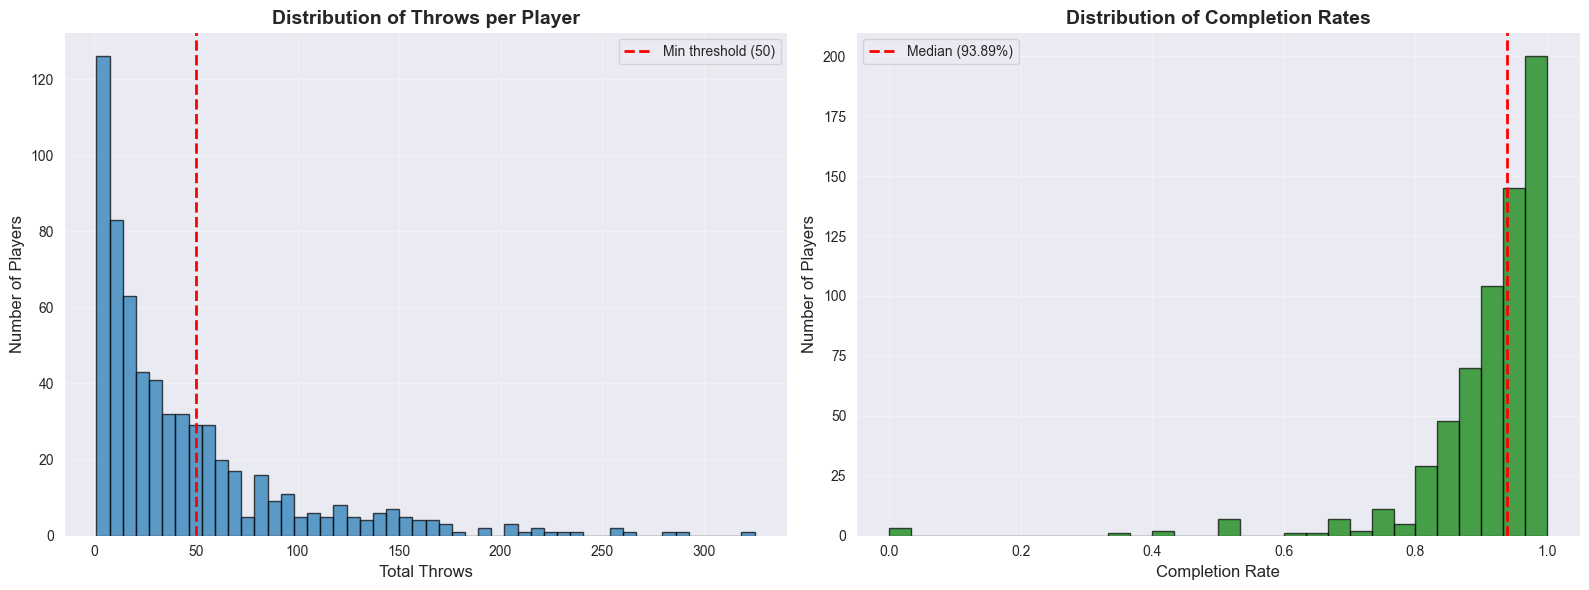

In [8]:
# Plot distribution of throws per player
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of throws per player
axes[0].hist(player_stats['total_throws'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(min_throws, color='red', linestyle='--', linewidth=2, label=f'Min threshold ({min_throws})')
axes[0].set_xlabel('Total Throws', fontsize=12)
axes[0].set_ylabel('Number of Players', fontsize=12)
axes[0].set_title('Distribution of Throws per Player', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Completion rate distribution
axes[1].hist(player_stats['completion_rate'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(player_stats['completion_rate'].median(), color='red', linestyle='--', 
                linewidth=2, label=f'Median ({player_stats["completion_rate"].median():.2%})')
axes[1].set_xlabel('Completion Rate', fontsize=12)
axes[1].set_ylabel('Number of Players', fontsize=12)
axes[1].set_title('Distribution of Completion Rates', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

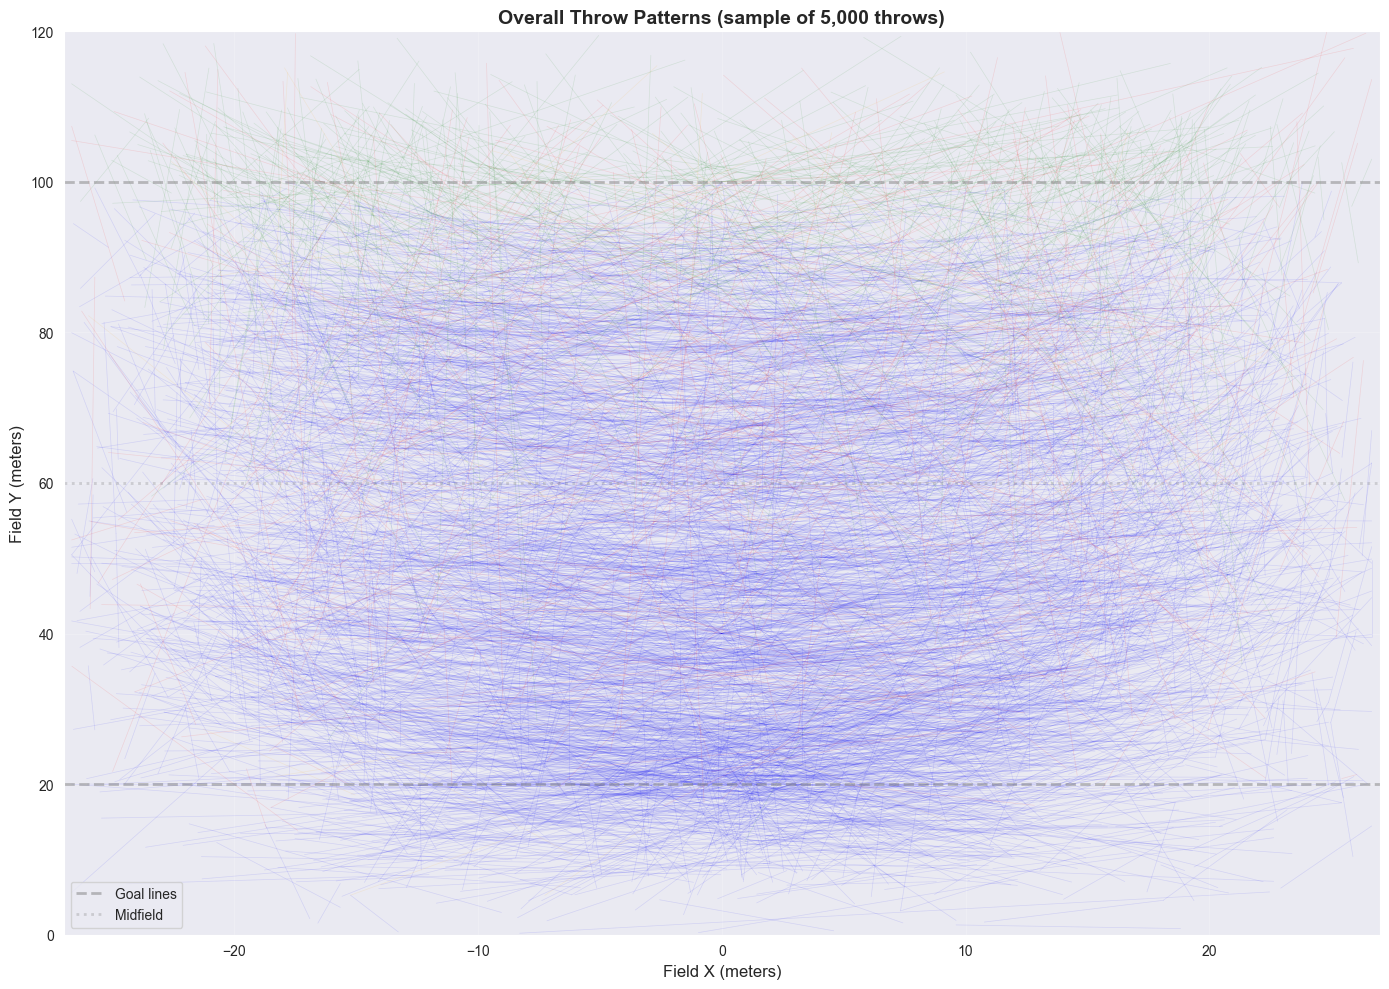

In [9]:
# Overall throw pattern visualization
fig, ax = plt.subplots(figsize=(14, 10))

# Sample 5000 throws for visualization (to avoid overcrowding)
sample_df = df.sample(min(5000, len(df)))

# Plot throws by type
for event_name, color in zip(['Throw (completion)', 'Goal', 'Drop', 'Throwaway'],
                              ['blue', 'green', 'orange', 'red']):
    data = sample_df[sample_df['event_name'] == event_name]
    
    for _, row in data.iterrows():
        ax.plot([row['thrower_x'], row['dest_x']], 
               [row['thrower_y'], row['dest_y']], 
               color=color, alpha=0.1, linewidth=0.5)

# Field markings
ax.axhline(y=20, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='Goal lines')
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, linewidth=2)
ax.axhline(y=60, color='gray', linestyle=':', alpha=0.3, linewidth=2, label='Midfield')

# Field boundaries
ax.set_xlim(-27, 27)
ax.set_ylim(0, 120)
ax.set_xlabel('Field X (meters)', fontsize=12)
ax.set_ylabel('Field Y (meters)', fontsize=12)
ax.set_title(f'Overall Throw Patterns (sample of {len(sample_df):,} throws)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

## 5. Player-Specific Visualization

Visualizing top player: lyorgason


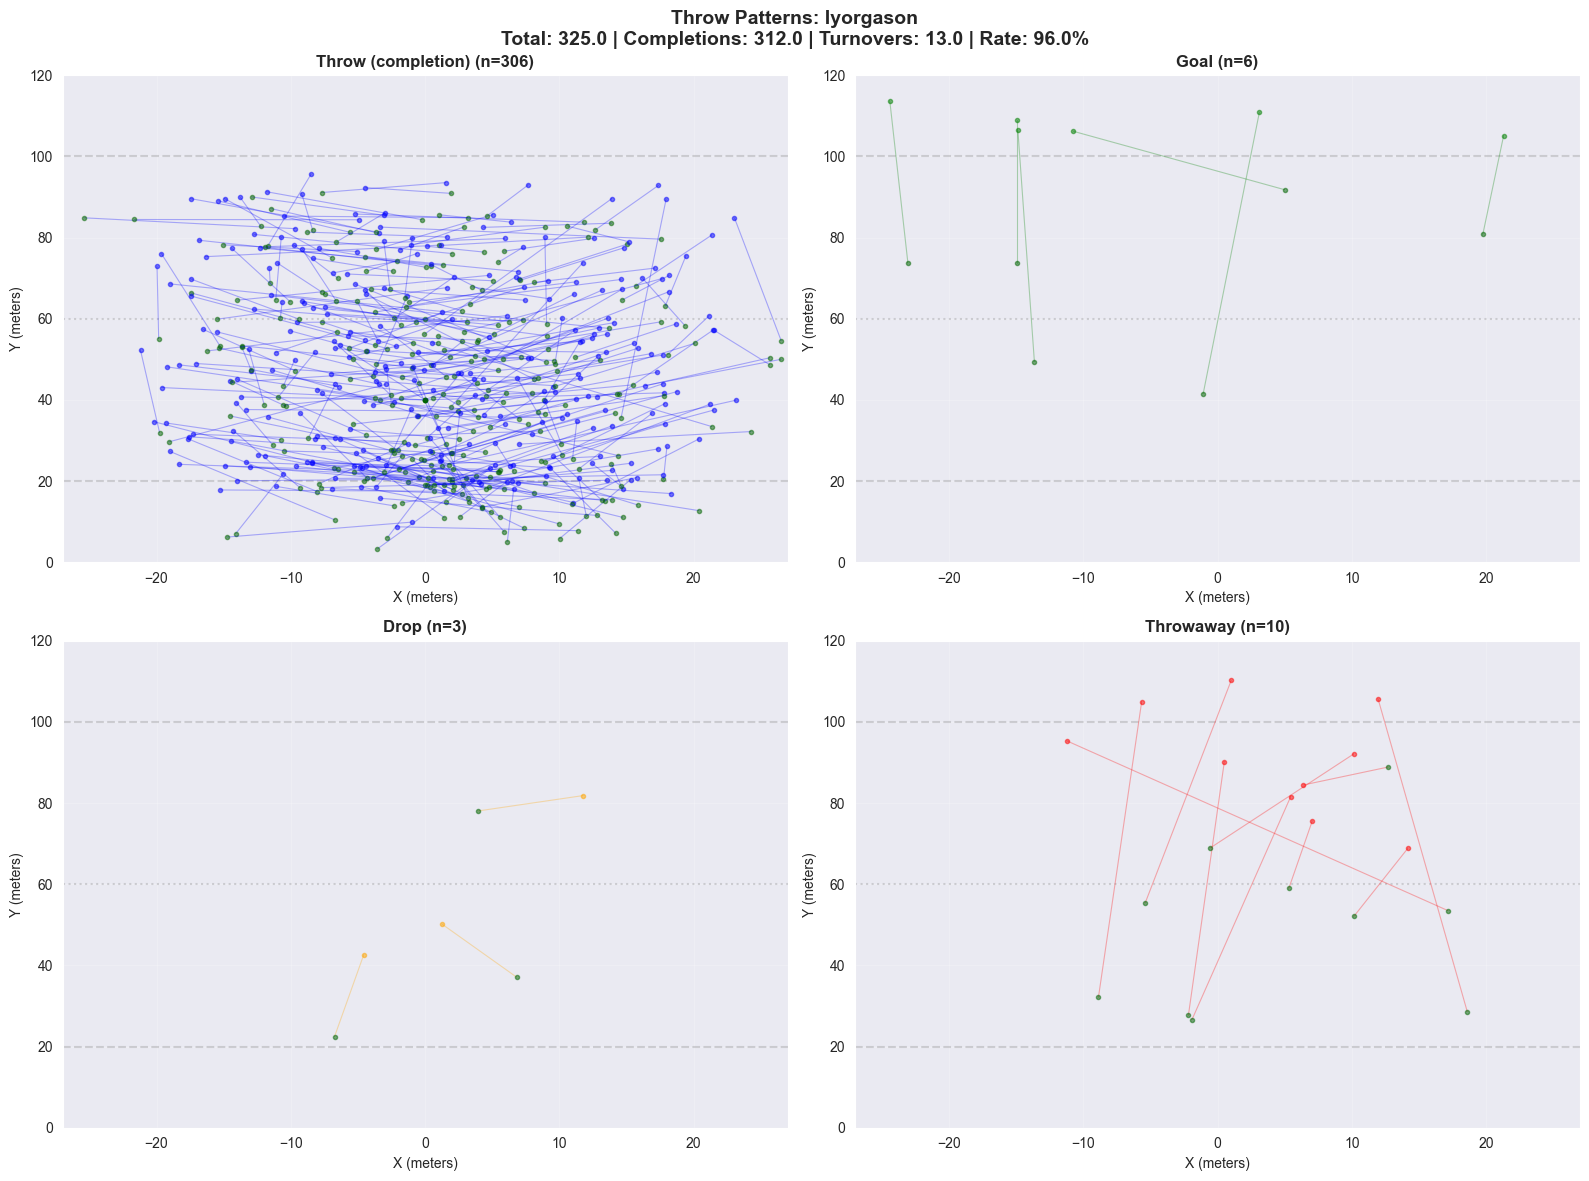

In [10]:
def visualize_player_throws(player_id):
    """Visualize throw patterns for a specific player."""
    player_data = df[df['player_id'] == player_id]
    
    if len(player_data) == 0:
        print(f"No data found for player: {player_id}")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    event_types = [
        ('Throw (completion)', 18, 'blue'),
        ('Goal', 19, 'green'),
        ('Drop', 20, 'orange'),
        ('Throwaway', 22, 'red')
    ]
    
    for idx, (name, etype, color) in enumerate(event_types):
        ax = axes[idx // 2, idx % 2]
        data = player_data[player_data['event_type'] == etype]
        
        # Plot field
        ax.set_xlim(-27, 27)
        ax.set_ylim(0, 120)
        ax.axhline(y=20, color='gray', linestyle='--', alpha=0.3)
        ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
        ax.axhline(y=60, color='gray', linestyle=':', alpha=0.3)
        
        # Plot throws
        for _, row in data.iterrows():
            ax.plot([row['thrower_x'], row['dest_x']], 
                   [row['thrower_y'], row['dest_y']], 
                   color=color, alpha=0.3, linewidth=0.8)
            ax.plot(row['thrower_x'], row['thrower_y'], 'o', color='darkgreen', markersize=3, alpha=0.5)
            ax.plot(row['dest_x'], row['dest_y'], 'o', color=color, markersize=3, alpha=0.5)
        
        ax.set_title(f'{name} (n={len(data)})', fontsize=12, fontweight='bold')
        ax.set_xlabel('X (meters)')
        ax.set_ylabel('Y (meters)')
        ax.grid(True, alpha=0.2)
    
    # Get player stats
    stats = player_stats.loc[player_id]
    fig.suptitle(
        f'Throw Patterns: {player_id}\n'
        f'Total: {stats["total_throws"]} | Completions: {stats["completions"]} | '
        f'Turnovers: {stats["turnovers"]} | Rate: {stats["completion_rate"]:.1%}',
        fontsize=14, fontweight='bold'
    )
    
    plt.tight_layout()
    plt.show()

# Example: visualize top player
top_player = player_stats.index[0]
print(f"Visualizing top player: {top_player}")
visualize_player_throws(top_player)

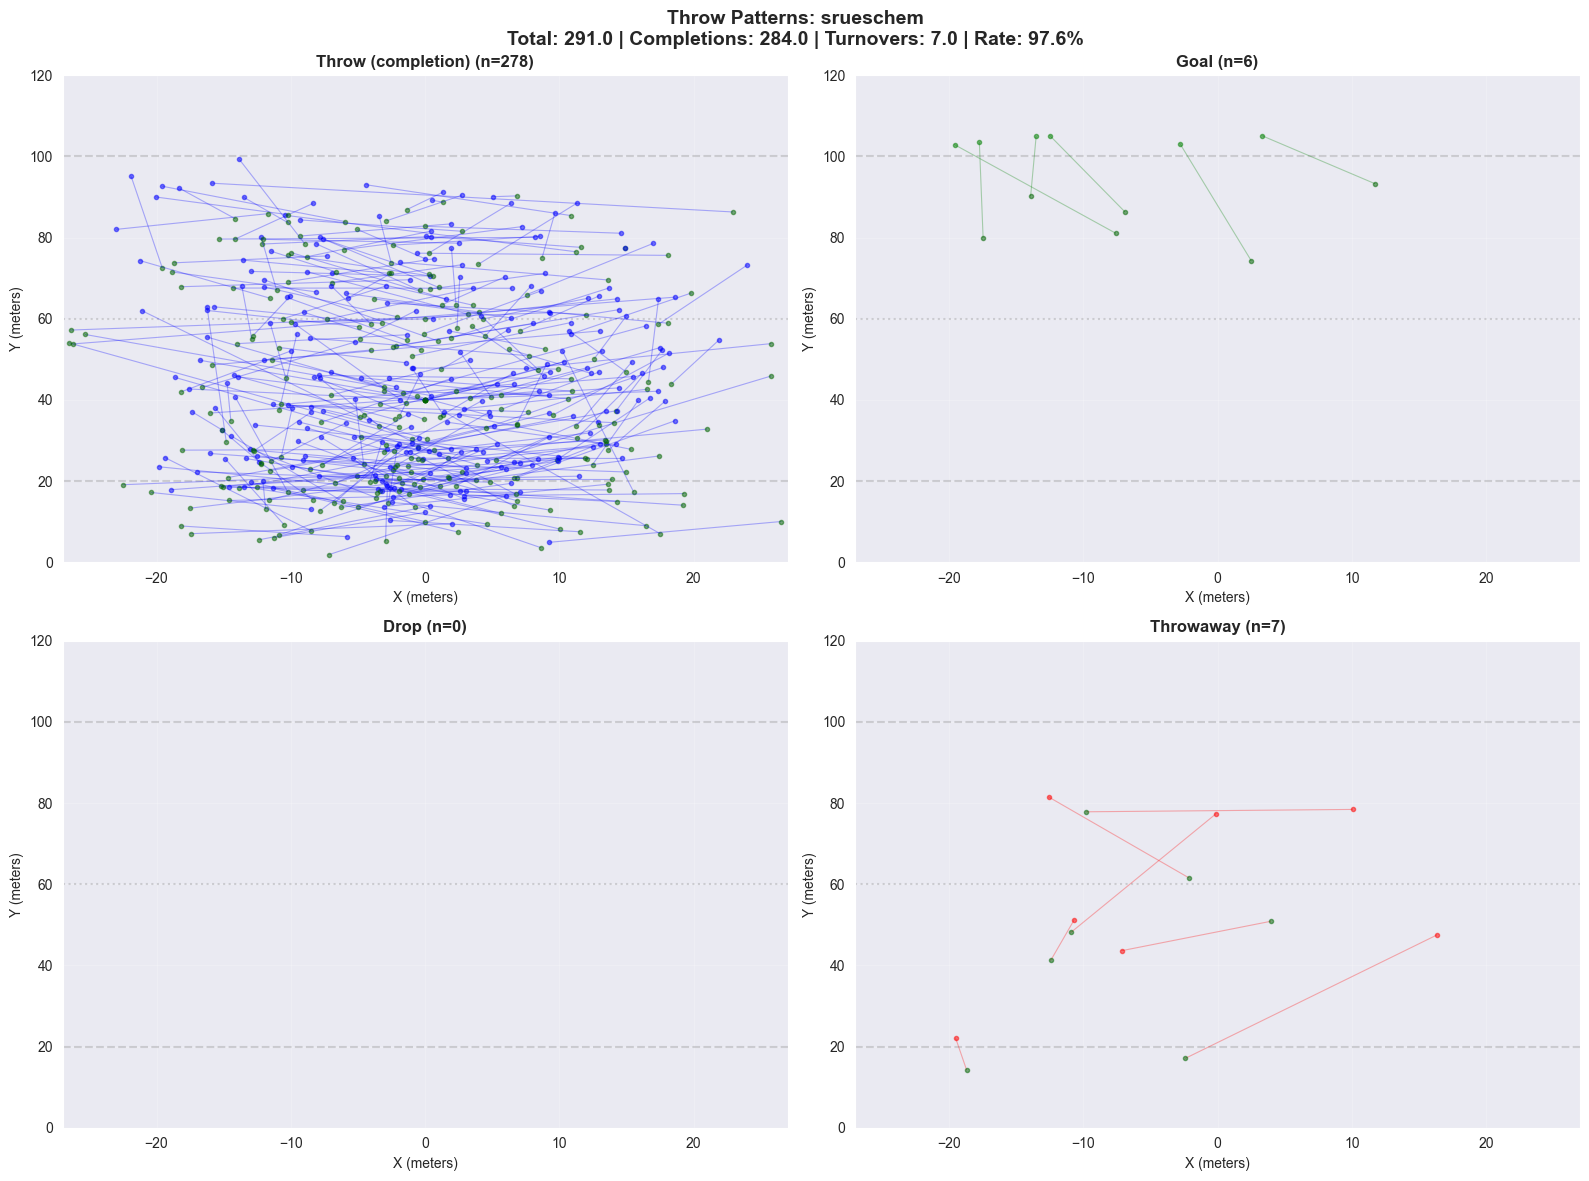

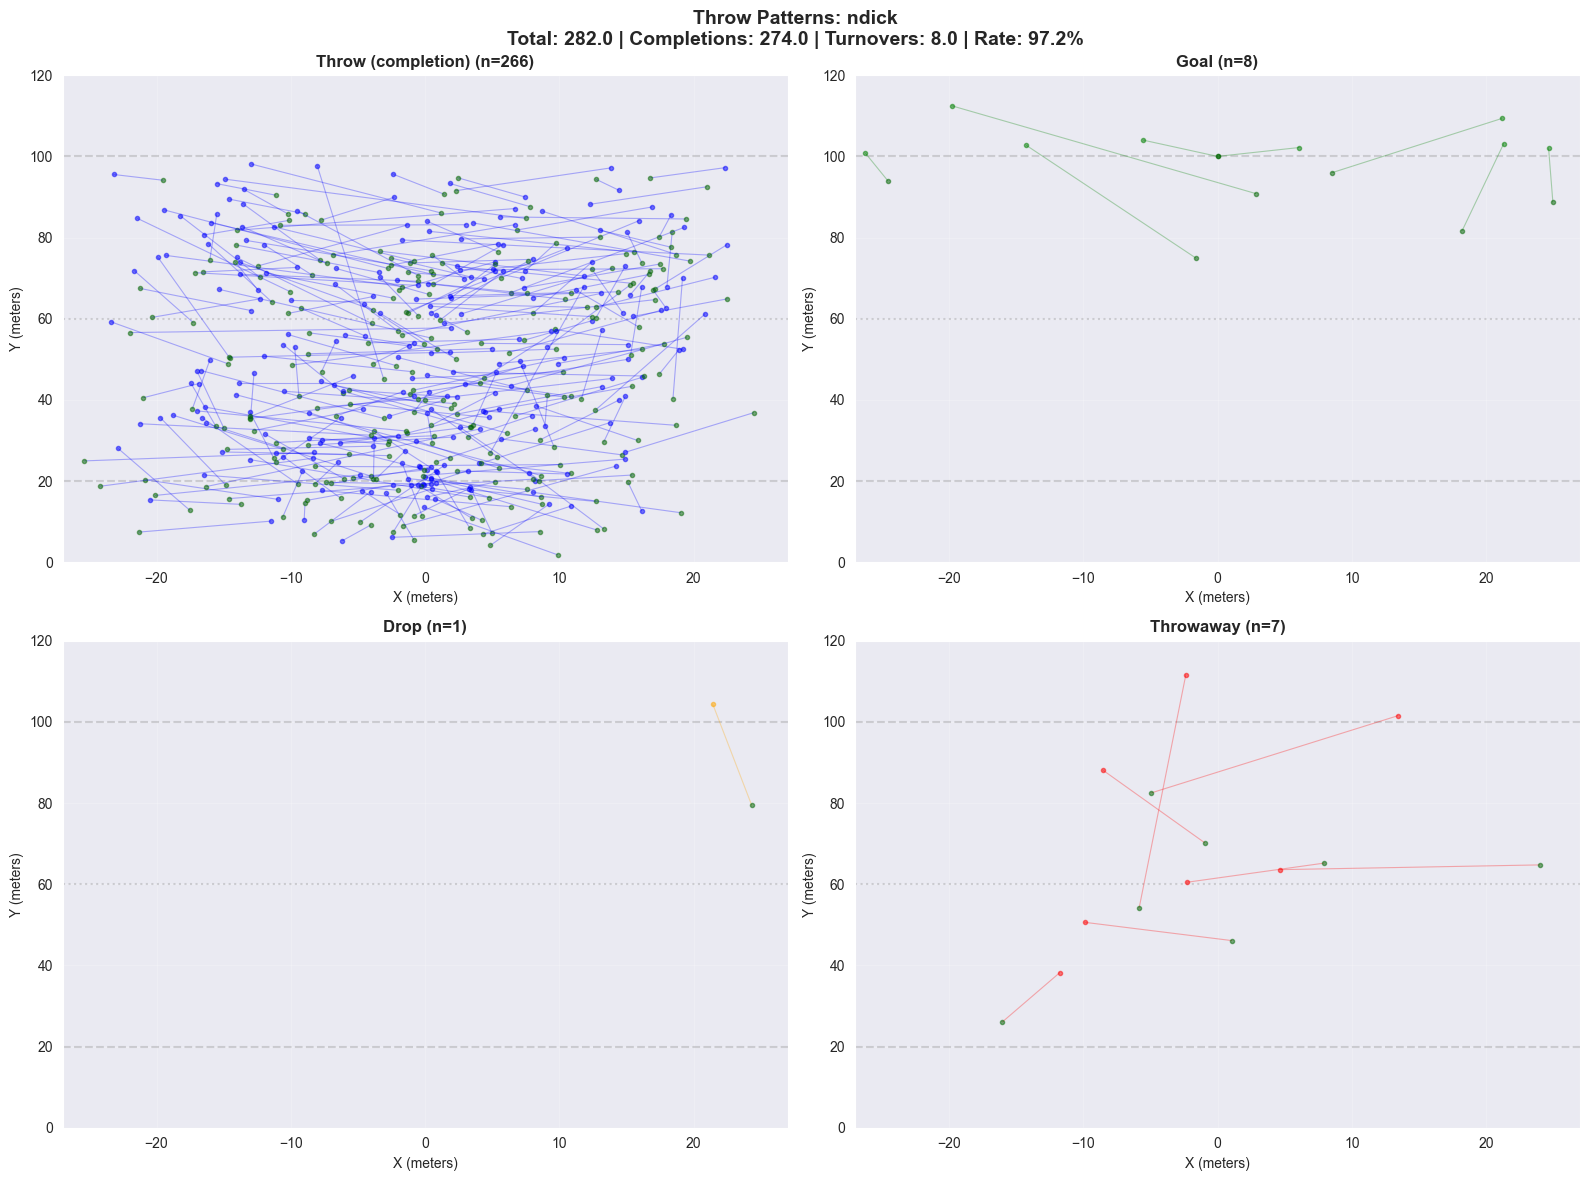

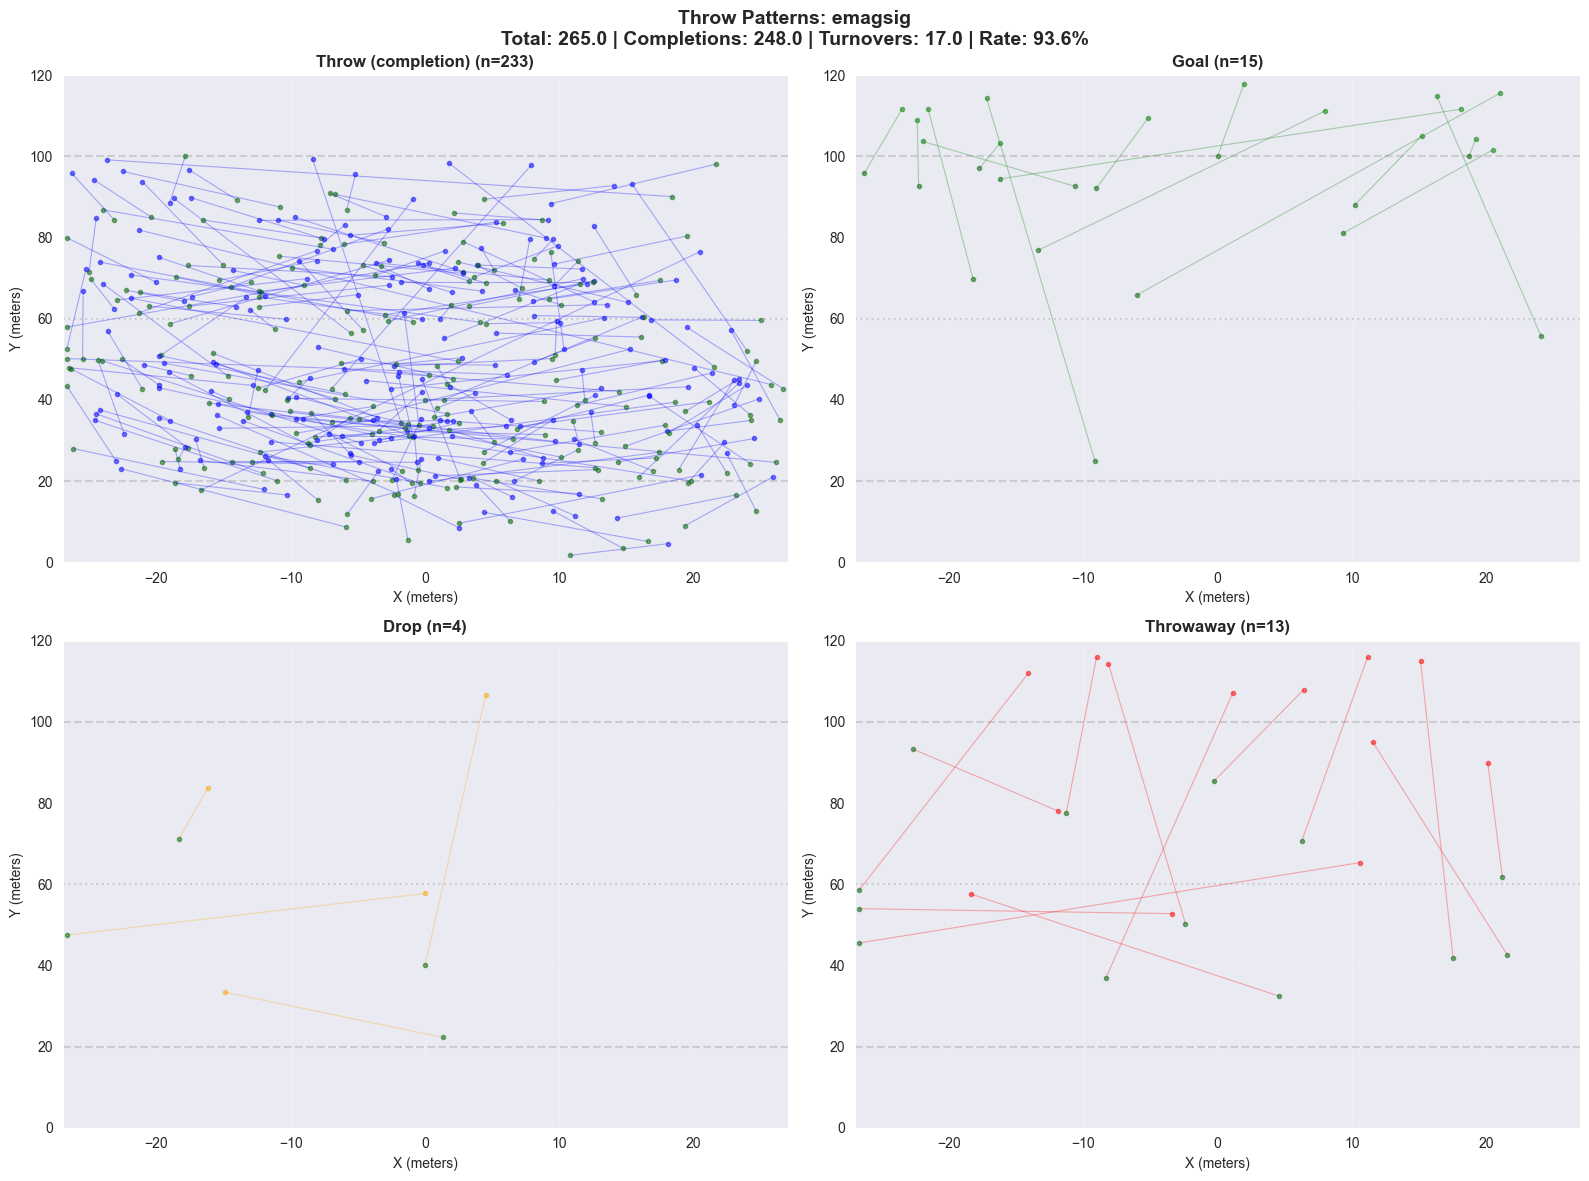

In [11]:
# Visualize a few more top players
for player in player_stats.index[1:4]:
    visualize_player_throws(player)

## 6. Save Filtered Dataset

In [12]:
# Save filtered dataset for MDN training (players with 50+ throws)
df_filtered = df[df['player_id'].isin(qualified_players.index)].copy()

print(f"Filtered dataset size: {len(df_filtered):,} events")
print(f"Players: {df_filtered['player_id'].nunique()}")
print(f"\nEvent type breakdown:")
print(df_filtered['event_name'].value_counts())

# Save to CSV for later use
output_file = 'throw_data_for_mdn.csv'
df_filtered.to_csv(output_file, index=False)
print(f"\nSaved to {output_file}")

Filtered dataset size: 20,783 events
Players: 200

Event type breakdown:
event_name
Throw (completion)    18177
Goal                   1326
Throwaway              1099
Drop                    181
Name: count, dtype: int64

Saved to throw_data_for_mdn.csv


## 7. Data Quality Checks

In [13]:
# Check for missing values
print("Missing values:")
print(df_filtered.isnull().sum())

# Check for outliers in coordinates
print("\nCoordinate ranges (should be within field bounds):")
print(f"Thrower X: [{df_filtered['thrower_x'].min():.1f}, {df_filtered['thrower_x'].max():.1f}] (expected: [-25, 25])")
print(f"Thrower Y: [{df_filtered['thrower_y'].min():.1f}, {df_filtered['thrower_y'].max():.1f}] (expected: [0, 120])")
print(f"Dest X:    [{df_filtered['dest_x'].min():.1f}, {df_filtered['dest_x'].max():.1f}] (expected: [-25, 25])")
print(f"Dest Y:    [{df_filtered['dest_y'].min():.1f}, {df_filtered['dest_y'].max():.1f}] (expected: [0, 120])")

# Count outliers
outliers = (
    (df_filtered['thrower_x'] < -25) | (df_filtered['thrower_x'] > 25) |
    (df_filtered['thrower_y'] < 0) | (df_filtered['thrower_y'] > 120) |
    (df_filtered['dest_x'] < -25) | (df_filtered['dest_x'] > 25) |
    (df_filtered['dest_y'] < 0) | (df_filtered['dest_y'] > 120)
)
print(f"\nOutliers (outside field bounds): {outliers.sum()} ({(outliers.sum()/len(df_filtered))*100:.2f}%)")

Missing values:
player_id     0
thrower_x     0
thrower_y     0
event_type    0
dest_x        0
dest_y        0
event_name    0
dtype: int64

Coordinate ranges (should be within field bounds):
Thrower X: [-26.7, 26.7] (expected: [-25, 25])
Thrower Y: [0.0, 100.0] (expected: [0, 120])
Dest X:    [-26.7, 26.7] (expected: [-25, 25])
Dest Y:    [0.0, 120.0] (expected: [0, 120])

Outliers (outside field bounds): 699 (3.36%)


## Summary

This notebook has:
1. Queried all throw events from the database (throws, goals, throwaways, drops)
2. Analyzed player-level statistics
3. Visualized throw patterns
4. Filtered data for players with sufficient throw volume (50+ throws)
5. Saved the filtered dataset for MDN training

**Next Steps:**
- Use the filtered dataset to train the Mixture Density Network
- Implement the MDN architecture in PyTorch
- Train the model to predict throw distributions based on player and position